# 1.2 MLE ile Akilli Sehir Planlamasi

Bu notebook, YZM212 Makine Ogrenmesi dersi 2. laboratuvar odevindeki Poisson dagilimi ve Maximum Likelihood Estimation (MLE) gorevlerini "Akilli Sehir Planlamasi" senaryosu uzerinden cozer.

Notebook akisi:
- Teorik turetme ile Poisson MLE tahmincisinin aritmetik ortalama oldugunu gosterme
- Python ile sayisal MLE hesaplama
- Histogram + Poisson PMF gorsellestirmesi
- Outlier etkisinin trafik planlamasi uzerinden yorumlanmasi

## Bolum 1: Teorik Cozumler

Bir dakikada gecen arac sayisi $k$ olsun ve bunun Poisson dagilimina uydugunu varsayalim:

$$
P(K = k \mid \lambda) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \ldots
$$

$n$ adet gozlem icin veri seti $\{k_1, k_2, \ldots, k_n\}$ oldugunda olabilirlik fonksiyonu:

$$
L(\lambda) = \prod_{i=1}^{n} \frac{e^{-\lambda} \lambda^{k_i}}{k_i!}
= e^{-n\lambda} \lambda^{\sum_i k_i} \prod_{i=1}^{n} \frac{1}{k_i!}
$$

Dogal logaritma alinirsa log-likelihood fonksiyonu:

$$
\ell(\lambda) = \log L(\lambda)
= \sum_{i=1}^{n} \left(-\lambda + k_i \log \lambda - \log(k_i!)\right)
$$

$$
\ell(\lambda) = -n\lambda + \left(\sum_{i=1}^{n} k_i\right) \log \lambda - \sum_{i=1}^{n} \log(k_i!)
$$

$\lambda$'ya gore turev alinip sifira esitlenirse:

$$
\frac{d\ell(\lambda)}{d\lambda} = -n + \frac{\sum_{i=1}^{n} k_i}{\lambda} = 0
$$

$$
\frac{\sum_{i=1}^{n} k_i}{\lambda} = n
\Rightarrow \hat{\lambda}_{MLE} = \frac{1}{n} \sum_{i=1}^{n} k_i
$$

Sonuc olarak Poisson dagilimi icin en yuksek olabilirlik tahmini, verilerin aritmetik ortalamasidir.

## Bolum 2: Python ile Sayisal MLE

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy.stats import poisson

plt.style.use('seaborn-v0_8-whitegrid')

BASE_DIR = Path.cwd()
if BASE_DIR.name != '1.2 MLE Akilli Sehir Planlamasi':
    BASE_DIR = BASE_DIR / '1.2 MLE Akilli Sehir Planlamasi'
FIG_DIR = BASE_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Gozlemlenen trafik verisi (1 dakikada gecen arac sayisi)
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15], dtype=float)

sample_size = len(traffic_data)
analytic_lambda = np.mean(traffic_data)

print(f'Gozlem sayisi: {sample_size}')
print(f'Ornek ortalama (analitik MLE): {analytic_lambda:.6f}')

Gozlem sayisi: 14
Ornek ortalama (analitik MLE): 12.142857


In [3]:
def negative_log_likelihood(lam, data):
    """Poisson dagilimi icin negatif log-likelihood hesaplar.

    log(k!) terimi lam'a bagli olmadigi icin optimizasyon sonucunu degistirmez;
    bu nedenle hesaplamada sabit terim olarak ihmal edilebilir.
    """
    lam = float(np.atleast_1d(lam)[0])

    if lam <= 0:
        return np.inf

    n = len(data)
    return n * lam - np.sum(data) * np.log(lam)


initial_guess = np.array([1.0])
result = optimize.minimize(
    negative_log_likelihood,
    initial_guess,
    args=(traffic_data,),
    bounds=[(1e-6, None)],
)

numerical_lambda = result.x[0]
difference = abs(numerical_lambda - analytic_lambda)

print(f'Sayisal Tahmin (MLE lambda): {numerical_lambda:.6f}')
print(f'Analitik Tahmin (Ortalama): {analytic_lambda:.6f}')
print(f'Mutlak fark: {difference:.10f}')
print(f'Optimizasyon basarili mi?: {result.success}')
print(f'Negatif log-likelihood: {result.fun:.6f}')

Sayisal Tahmin (MLE lambda): 12.142857
Analitik Tahmin (Ortalama): 12.142857
Mutlak fark: 0.0000002397
Optimizasyon basarili mi?: True
Negatif log-likelihood: -254.445988


Sayisal optimizasyon sonucu ile analitik cozum neredeyse tamamen cakismaktadir. Bu da Poisson dagilimi icin MLE tahmincisinin ornek ortalama oldugu teorik sonucunu sayisal olarak dogrular.

## Bolum 3: Model Karsilastirma ve Gorsellestirme

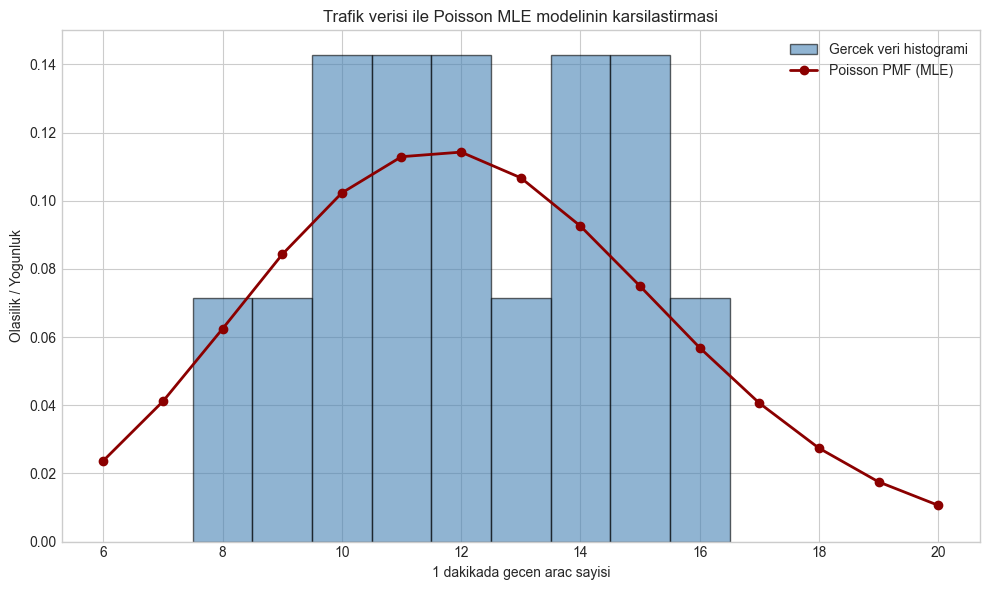

Ortalama: 12.1429
Varyans: 5.5510


In [4]:
sample_variance = np.var(traffic_data, ddof=0)
x_values = np.arange(int(traffic_data.min()) - 2, int(traffic_data.max()) + 5)
pmf_values = poisson.pmf(x_values, mu=numerical_lambda)

fig, ax = plt.subplots(figsize=(10, 6))
bins = np.arange(traffic_data.min() - 0.5, traffic_data.max() + 1.5, 1)
ax.hist(
    traffic_data,
    bins=bins,
    density=True,
    alpha=0.6,
    color='steelblue',
    edgecolor='black',
    label='Gercek veri histogrami',
)
ax.plot(x_values, pmf_values, 'o-', color='darkred', linewidth=2, label='Poisson PMF (MLE)')
ax.set_xlabel('1 dakikada gecen arac sayisi')
ax.set_ylabel('Olasilik / Yogunluk')
ax.set_title('Trafik verisi ile Poisson MLE modelinin karsilastirmasi')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'poisson_fit.png', dpi=160)
plt.show()

print(f'Ortalama: {analytic_lambda:.4f}')
print(f'Varyans: {sample_variance:.4f}')

### Gorsel Yorum

- Histogramin merkezi 11-14 araliginda yogunlasmaktadir ve Poisson PMF de benzer merkez etrafinda tepe yapmaktadir.
- Bu nedenle model, trafik akisinin genel merkezini iyi temsil etmektedir.
- Ancak ornek varyans ($\approx 5.55$), ortalamadan ($\approx 12.14$) belirgin bicimde daha kucuktur. Bu durum verinin Poisson varsayimina gore biraz daha dar yayildigini gosterir.
- Dolayisiyla model makul bir ilk yaklasim saglasa da veri, tam bir Poisson yapisindan daha duzenli gorunmektedir.

## Bolum 4: Gercek Hayat Senaryosu - Outlier Analizi

In [5]:
traffic_with_outlier = np.append(traffic_data, 200)
analytic_lambda_outlier = np.mean(traffic_with_outlier)

result_outlier = optimize.minimize(
    negative_log_likelihood,
    initial_guess,
    args=(traffic_with_outlier,),
    bounds=[(1e-6, None)],
)

numerical_lambda_outlier = result_outlier.x[0]
increase_ratio = analytic_lambda_outlier / analytic_lambda

print(f'Outlier eklendikten sonra analitik MLE: {analytic_lambda_outlier:.6f}')
print(f'Outlier eklendikten sonra sayisal MLE: {numerical_lambda_outlier:.6f}')
print(f'Artis katsayisi: {increase_ratio:.4f}x')
print(f'Yuzde artis: {(increase_ratio - 1) * 100:.2f}%')

Outlier eklendikten sonra analitik MLE: 24.666667
Outlier eklendikten sonra sayisal MLE: 24.666695
Artis katsayisi: 2.0314x
Yuzde artis: 103.14%


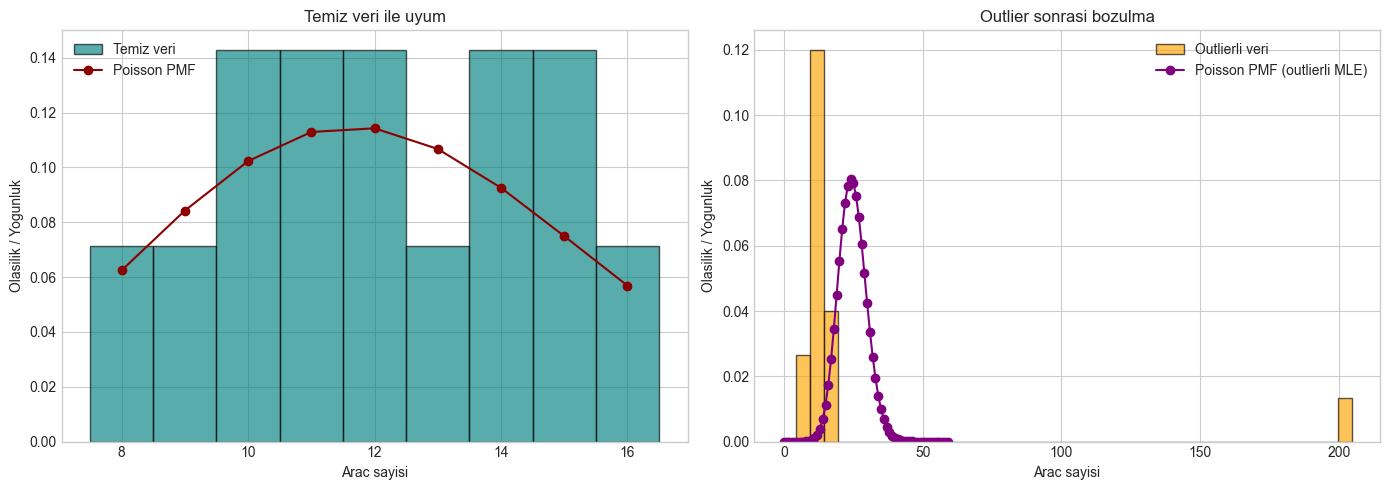

In [6]:
x_outlier = np.arange(0, 60)
pmf_clean = poisson.pmf(x_outlier, mu=analytic_lambda)
pmf_outlier = poisson.pmf(x_outlier, mu=analytic_lambda_outlier)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(traffic_data, bins=np.arange(7.5, 17.5, 1), density=True, alpha=0.65, color='teal', edgecolor='black', label='Temiz veri')
axes[0].plot(np.arange(8, 17), poisson.pmf(np.arange(8, 17), mu=analytic_lambda), 'o-', color='darkred', label='Poisson PMF')
axes[0].set_title('Temiz veri ile uyum')
axes[0].set_xlabel('Arac sayisi')
axes[0].set_ylabel('Olasilik / Yogunluk')
axes[0].legend()

axes[1].hist(traffic_with_outlier, bins=np.arange(-0.5, 205.5, 5), density=True, alpha=0.65, color='orange', edgecolor='black', label='Outlierli veri')
axes[1].plot(x_outlier, pmf_outlier, 'o-', color='purple', label='Poisson PMF (outlierli MLE)')
axes[1].set_title('Outlier sonrasi bozulma')
axes[1].set_xlabel('Arac sayisi')
axes[1].set_ylabel('Olasilik / Yogunluk')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / 'outlier_impact.png', dpi=160)
plt.show()

### Outlier Etkisi ve Akilli Sehir Planlamasi Yorumu

- Poisson MLE tahmincisi dogrudan ornek ortalamasi oldugu icin, tek bir asiri buyuk deger bile $\hat{\lambda}$ tahminini ciddi bicimde yukari iter.
- Bu veri setinde tek bir `200` gozlemi, tahmini ortalamayi yaklasik **2.03 katina** cikarmaktadir.
- Belediyenin bu bozuk tahmine dayanarak yol genisletme, sinyalizasyon artirma veya yeni serit planlama karari almasi, gercek ihtiyacin uzerinde altyapi yatirimi yapmasina yol acabilir.
- Bu nedenle uygulamada aykiri deger analizi, veri temizligi ve alternatif saglam (robust) yontemler kritik oneme sahiptir.

## Sonuc

Bu calismada Poisson dagilimi icin MLE tahmincisinin teorik olarak aritmetik ortalama oldugu gosterildi ve Python ile sayisal olarak dogrulandi. Temiz veri icin model makul bir uyum saglarken, tek bir aykiri gozlemin MLE tahminini ciddi bicimde bozdugu ve sehir planlamasi kararlarini yaniltabilecegi goruldu.